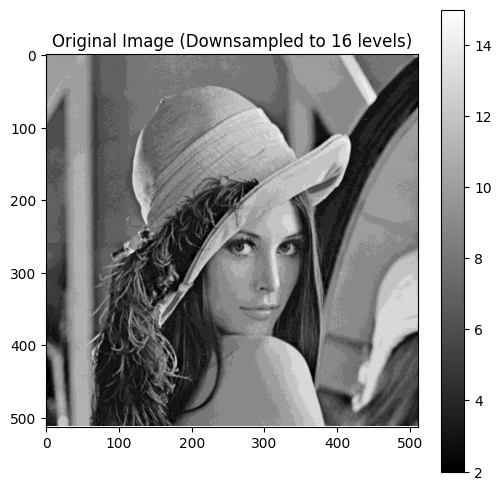

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the image in grayscale
img = cv2.imread('input.png', cv2.IMREAD_GRAYSCALE)

# 2. Downsample pixel values to 0-15 (16 levels) to keep the GLCM size manageable
# Standard 256 levels create a 256x256 matrix, which is often sparse.
levels = 16
img_resized = (img // (256 // levels)).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(img_resized, cmap='gray')
plt.title(f"Original Image (Downsampled to {levels} levels)")
plt.colorbar()
plt.show()

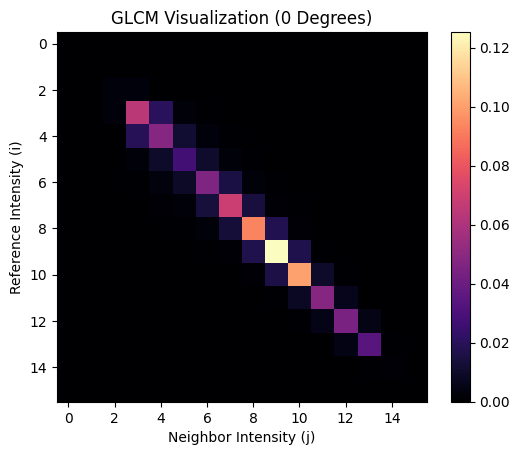

In [7]:
def compute_glcm(image, distance, angle, levels):
    h, w = image.shape
    glcm = np.zeros((levels, levels), dtype=np.uint32)
    
    # Define offsets based on angle
    # 0 deg: (0, d), 90 deg: (-d, 0), 45 deg: (-d, d), 135 deg: (-d, -d)
    dy, dx = 0, 0
    if angle == 0:   dy, dx = 0, distance
    elif angle == 45:  dy, dx = -distance, distance
    elif angle == 90:  dy, dx = -distance, 0
    elif angle == 135: dy, dx = -distance, -distance

    for y in range(h):
        for x in range(w):
            ny, nx = y + dy, x + dx
            
            # Check if neighbor is within bounds
            if 0 <= ny < h and 0 <= nx < w:
                i = image[y, x]
                j = image[ny, nx]
                glcm[i, j] += 1
                
    # Normalize the matrix to get probabilities
    return glcm / np.sum(glcm)

# Example: Compute for Horizontal relationship (d=1, theta=0)
glcm_0 = compute_glcm(img_resized, distance=1, angle=0, levels=levels)

plt.imshow(glcm_0, cmap='magma')
plt.title("GLCM Visualization (0 Degrees)")
plt.xlabel("Neighbor Intensity (j)")
plt.ylabel("Reference Intensity (i)")
plt.colorbar()
plt.show()

In [3]:
def extract_features(P):
    levels = P.shape[0]
    contrast = 0
    homogeneity = 0
    energy = 0
    
    # For correlation, we need means and standard deviations
    i_indices, j_indices = np.indices((levels, levels))
    
    mu_i = np.sum(i_indices * P)
    mu_j = np.sum(j_indices * P)
    sigma_i = np.sqrt(np.sum(P * (i_indices - mu_i)**2))
    sigma_j = np.sqrt(np.sum(P * (j_indices - mu_j)**2))
    
    correlation = 0
    
    for i in range(levels):
        for j in range(levels):
            contrast += P[i, j] * (i - j)**2
            homogeneity += P[i, j] / (1 + (i - j)**2)
            energy += P[i, j]**2
            if sigma_i > 0 and sigma_j > 0:
                correlation += P[i, j] * ((i - mu_i) * (j - mu_j)) / (sigma_i * sigma_j)
                
    return contrast, homogeneity, np.sqrt(energy), correlation

stats = extract_features(glcm_0)
print(f"Contrast: {stats[0]:.4f}\nHomogeneity: {stats[1]:.4f}\nEnergy: {stats[2]:.4f}\nCorrelation: {stats[3]:.4f}")

Contrast: 0.5402
Homogeneity: 0.8384
Energy: 0.2400
Correlation: 0.9660


In [6]:
# Updated loop to include Correlation in the printout
print(f"{'Angle':<10} | {'Contrast':<10} | {'Homogeneity':<12} | {'Energy':<10} | {'Correlation':<12}")
print("-" * 75)

for ang in angles:
    # 1. Compute GLCM for current angle
    mat = compute_glcm(img_resized, distance=1, angle=ang, levels=levels)
    
    # 2. Extract all 4 features
    # f[0]=Contrast, f[1]=Homogeneity, f[2]=Energy, f[3]=Correlation
    f = extract_features(mat)
    results[ang] = f
    
    # 3. Print the row
    print(f"{ang:<10} | {f[0]:<10.3f} | {f[1]:<12.3f} | {f[2]:<10.3f} | {f[3]:<12.3f}")

Angle      | Contrast   | Homogeneity  | Energy     | Correlation 
---------------------------------------------------------------------------
0          | 0.540      | 0.838        | 0.240      | 0.966       
45         | 0.591      | 0.836        | 0.240      | 0.963       
90         | 0.337      | 0.876        | 0.255      | 0.979       
135        | 0.733      | 0.817        | 0.232      | 0.954       
